# DesInventar — Pipeline & Source EDA
**Montandon ETL · Togglecorp**

Scope: all 100 DesInventar country codes from a full local re-extraction.

This notebook answers one question: **of the data DesInventar publishes, how much reaches
Montandon, and where does the rest go?** It separates *source* problems (the archives are
genuinely bad) from *pipeline* problems (we drop data that arrived fine) — the distinction
that determines whether a fix belongs to us or to UNDRR.

---
### Inputs
Generated by two read-only management commands (neither writes to the database):

```bash
docker compose exec web python manage.py export_desinventar_eda
docker compose exec web python manage.py audit_desinventar_source
```

| File | Grain | Produced by |
|---|---|---|
| `pipeline.csv` | one row per country code | export — extraction & transform outcome |
| `items.parquet` | one row per STAC item (1.18 M) | export — flattened `PyStacLoadData.item` |
| `source_audit.csv` | one row per country | audit — replays the transformer's decision path |
| `hazard_unmapped.csv` | one row per unmatched hazard name | audit — with normalisation hint |

> **Note on the export script.** The in-house STAC upload script flips
> `PyStacLoadData.status` to `SUCCESS` as it writes. That is correct when *draining the
> load queue*, but wrong for analysis — it would silently mark items as loaded to eoAPI
> when they never were. The export command here deliberately omits that write.


## Setup


In [1]:
import warnings

warnings.filterwarnings("ignore")
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

DATA = Path("../data/desinventar_eda")

pipeline = pd.read_csv(DATA / "pipeline.csv")
audit = pd.read_csv(DATA / "source_audit.csv")
hazards = pd.read_csv(DATA / "hazard_unmapped.csv")
items = pd.read_parquet(DATA / "items.parquet")

events = items[items.item_type == "Event"]
impacts = items[items.item_type == "Impact"]

print(f"pipeline : {len(pipeline):>9,} country codes")
print(f"audit    : {len(audit):>9,} countries parsed from source archives")
print(f"items    : {len(items):>9,}  ({len(events):,} events / {len(impacts):,} impacts)")

pipeline :       100 country codes
audit    :        96 countries parsed from source archives
items    : 1,179,421  (553,062 events / 626,359 impacts)


## 1. The funnel — where countries drop out

Every stage below is a place a country can silently vanish. Note that *no* transform is
ever marked FAILED: DesInventar overrides `handle_transformation` and marks `SUCCESS`
unconditionally, so this table is the only way to see the attrition.


In [2]:
requested = len(pipeline)
downloaded = (pipeline.resp_code == 200).sum()
dispatched = pipeline.has_transform.sum()
produced = (pipeline.total_rows > 0).sum()
with_events = events.country_code.nunique()

funnel = pd.DataFrame(
    {
        "stage": [
            "Requested",
            "Downloaded (HTTP 200)",
            "Transform dispatched",
            "Transform produced rows",
            "Countries with events in DB",
        ],
        "countries": [requested, downloaded, dispatched, produced, with_events],
    }
)
funnel["lost_here"] = funnel.countries.diff().fillna(0).astype(int)
display(funnel)

print("\nDownloaded but never dispatched to the transformer:")
never = pipeline[(pipeline.resp_code == 200) & (~pipeline.has_transform)]
display(never[["country_code", "extraction_status", "resp_code"]])

print("\nDispatched, reported SUCCESS, but produced zero rows:")
display(
    pipeline[(pipeline.has_transform) & (pipeline.total_rows == 0)][
        ["country_code", "transform_status", "total_rows", "failed_rows"]
    ]
)

,stage,countries,lost_here
0,Requested,100,0
1,Downloaded (HTTP 200),96,-4
2,Transform dispatched,85,-11
3,Transform produced rows,78,-7
4,Countries with events in DB,73,-5



Downloaded but never dispatched to the transformer:


,country_code,extraction_status,resp_code
83,tur,Success,200
84,tza,Success,200
87,vct,Success,200
89,vnm,Success,200
90,xkx,Success,200
91,yem,Success,200
92,zmb,Success,200
96,znz,Success,200
97,019,Success,200
98,033,Success,200



Dispatched, reported SUCCESS, but produced zero rows:


,country_code,transform_status,total_rows,failed_rows
7,blr,Success,0,0
41,lao,Success,0,0
46,mar,Success,0,0
48,mdv,Success,0,0
51,mmr,Success,0,0
74,som,Success,0,0
78,syr,Success,0,0


## 2. Loss attribution — 908 k source rows in, 553 k events out

`source_audit.csv` replays the transformer's own branches per row, so each dropped row is
attributed to the branch that actually rejected it. Categories are mutually exclusive and
must reconcile exactly against the database count — the assertion below enforces that.


In [3]:
src_rows = int(audit.source_rows.sum())
would_keep = int(audit.kept.sum())
in_db = len(events)

# countries whose rows never reached the DB at all
no_transform = set(pipeline[~pipeline.has_transform].country_code)
zero_rows = set(pipeline[(pipeline.has_transform) & (pipeline.total_rows == 0)].country_code)

never_dispatched = int(audit[audit.country_code.isin(no_transform)].kept.sum())
silent_zero = int(audit[audit.country_code.isin(zero_rows)].kept.sum())

loss = pd.DataFrame(
    [
        ("Hazard name not in mapping", int(audit.hazard_unmapped.sum()), "pipeline"),
        (
            "Numeric ValidationError",
            int(audit.get("exception_ValidationError", pd.Series(dtype=float)).fillna(0).sum()),
            "pipeline",
        ),
        ("Never dispatched to transform", never_dispatched, "pipeline"),
        ("Silent zero-row country", silent_zero, "pipeline"),
        ("Unparseable event date", int(audit.bad_date.sum()), "source"),
        (
            "Missing XML field (KeyError)",
            int(audit.get("exception_KeyError", pd.Series(dtype=float)).fillna(0).sum()),
            "source",
        ),
    ],
    columns=["cause", "rows", "owner"],
).sort_values("rows", ascending=False)
loss["pct_of_source"] = (100 * loss.rows / src_rows).round(1)

print(f"source rows      {src_rows:>9,}")
print(f"events in DB     {in_db:>9,}")
print(f"lost             {src_rows - in_db:>9,}   ({100 * (src_rows - in_db) / src_rows:.1f}%)")
print(f"  of which ours  {loss[loss.owner == 'pipeline'].rows.sum():>9,}\n")
display(loss)

assert loss.rows.sum() == src_rows - in_db, "categories must reconcile exactly"
print("Reconciles exactly against the database count.")

source rows        908,446
events in DB       553,062
lost               355,384   (39.1%)
  of which ours    354,039



,cause,rows,owner,pct_of_source
0,Hazard name not in mapping,230299,pipeline,25.4
1,Numeric ValidationError,71629,pipeline,7.9
2,Never dispatched to transform,41121,pipeline,4.5
3,Silent zero-row country,10990,pipeline,1.2
4,Unparseable event date,1142,source,0.1
5,Missing XML field (KeyError),203,source,0.0


Reconciles exactly against the database count.


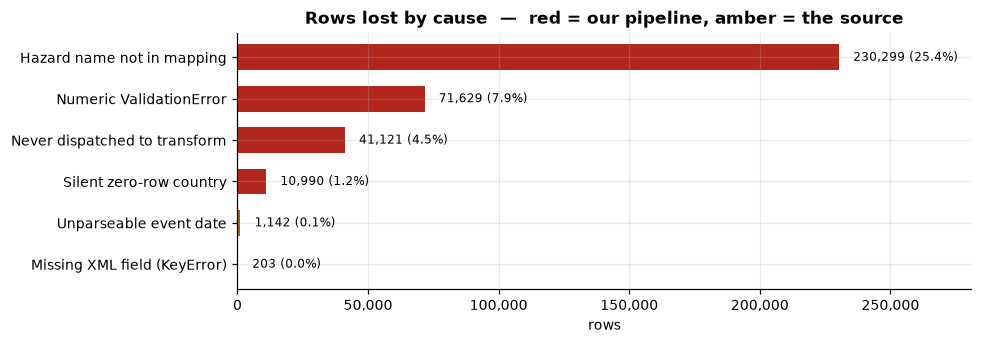

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.2))
colours = {"pipeline": "#b3261e", "source": "#a86400"}
ax.barh(loss.cause, loss.rows, color=[colours[o] for o in loss.owner], height=0.62)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for y, (n, p) in enumerate(zip(loss.rows, loss.pct_of_source)):
    ax.text(n + src_rows * 0.006, y, f"{n:,} ({p}%)", va="center", fontsize=8)
ax.set_xlim(0, loss.rows.max() * 1.22)
ax.set_title("Rows lost by cause  —  red = our pipeline, amber = the source", fontweight="bold")
ax.set_xlabel("rows")
plt.tight_layout()
plt.show()

## 3. Is the 'recent-year collapse' real?

Algo8 reported that African DesInventar coverage falls off a cliff after 2023 — 202 events
in 2024, 89 in 2025 — and asked whether that is a reporting lag. Compare the **source**
rows against what **loaded**, by year. If the source is thin, it's a genuine lag; if the
source is full, whatever they queried was simply stale.


In [5]:
AFRICA = {
    "ago",
    "bfa",
    "bdi",
    "com",
    "cpv",
    "dji",
    "egy",
    "eth",
    "gha",
    "gin",
    "gmb",
    "gnb",
    "gnq",
    "ken",
    "lbr",
    "mdg",
    "mli",
    "moz",
    "mus",
    "mwi",
    "nam",
    "ner",
    "nga",
    "rwa",
    "sdn",
    "sen",
    "sle",
    "som",
    "swz",
    "syc",
    "tgo",
    "tza",
    "uga",
    "zmb",
    "znz",
    "mar",
    "tun",
}

loaded = (
    events[events.year.between(2015, 2026)]
    .assign(africa=lambda d: d.country_code.isin(AFRICA))
    .groupby(["year", "africa"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: "africa_loaded", False: "rest_loaded"})
)
loaded["all_loaded"] = loaded.sum(axis=1)
display(loaded[["all_loaded", "africa_loaded"]].astype(int))

print("\nAlgo8 reported for African DesInventar:   2024 = 202 events,  2025 = 89 events")
print(
    f"This extraction:                          2024 = {loaded.africa_loaded.get(2024, 0):,} events, "
    f"2025 = {loaded.africa_loaded.get(2025, 0):,} events"
)

africa,all_loaded,africa_loaded
year,,
2015,9895,4492
2016,9385,4613
2017,10221,4760
2018,8655,3572
2019,10184,4866
2020,10837,10065
2021,7821,6533
2022,16929,16299
2023,21142,19816



Algo8 reported for African DesInventar:   2024 = 202 events,  2025 = 89 events
This extraction:                          2024 = 22,390 events, 2025 = 7,177 events


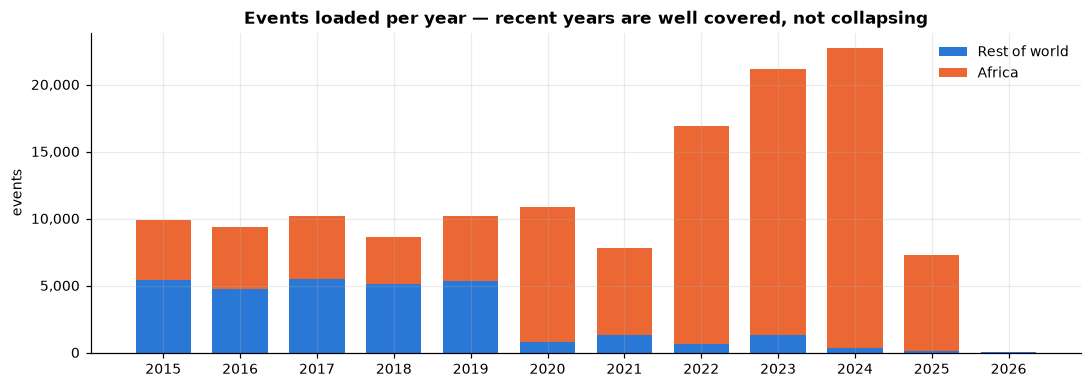

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.6))
yr = loaded.index
ax.bar(yr, loaded.rest_loaded, label="Rest of world", color="#2a78d6", width=0.72)
ax.bar(yr, loaded.africa_loaded, bottom=loaded.rest_loaded, label="Africa", color="#eb6834", width=0.72)
ax.set_xticks(list(yr))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_title("Events loaded per year — recent years are well covered, not collapsing", fontweight="bold")
ax.set_ylabel("events")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4. Hazard vocabulary — the single biggest loss

`hazard_mapping` is a 53-entry dict keyed on exact uppercase strings; any miss silently
drops the row. `hazard_unmapped.csv` classifies every unmatched name into three groups.
Only the third needs a taxonomy decision — the first is a pure string-normalisation fix.


In [7]:
summary = (
    hazards.groupby("classification")
    .agg(names=("hazard_name", "nunique"), rows=("rows", "sum"))
    .sort_values("rows", ascending=False)
)
display(summary)

print("\nRecoverable purely by case/space/plural normalisation:")
display(
    hazards[hazards.classification == "recoverable_by_normalisation"].nlargest(15, "rows")[
        ["hazard_name", "rows", "normalises_to"]
    ]
)

print("\nGenuinely missing from the taxonomy (needs a decision):")
display(hazards[hazards.classification == "missing_from_taxonomy"].nlargest(15, "rows")[["hazard_name", "rows"]])

,names,rows
classification,,
missing_from_taxonomy,445,132224
recoverable_by_normalisation,64,65369
explicitly_mapped_to_none,5,32706



Recoverable purely by case/space/plural normalisation:


,hazard_name,rows,normalises_to
2,FORESTFIRE,18766,FOREST FIRE
3,STRONGWIND,11584,STRONG WIND
6,FLOODS,10449,FLOOD
8,LANDSLIDES,6069,LANDSLIDE
20,Flashflood,2267,FLASH FLOOD
21,Forest fire,2087,FOREST FIRE
25,ELECTRICSTORM,1442,ELECTRIC STORM
26,HEATWAVE,1417,HEAT WAVE
30,Forest Fire,1275,FOREST FIRE
31,Flood,1247,FLOOD



Genuinely missing from the taxonomy (needs a decision):


,hazard_name,rows
0,MENINGITIS,27946
4,ROAD ACCIDENT,10951
5,ANIMAL ATTACK,10949
7,MEASLE,9581
10,STRUCTURE,5389
11,ANIN BOT,3886
12,SPATE,3531
13,DOMESTIC FIRE,2908
14,DROWNING,2828
16,HEAVY RAINS,2751


## 5. Worst-affected countries

`recoverable_by_normalisation` is the row count a case-insensitive lookup would restore
immediately, with no taxonomy work.


In [8]:
worst = audit.assign(lost=lambda d: d.source_rows - d.kept)
worst["loss_pct"] = (100 * worst.lost / worst.source_rows).round(1)
display(
    worst.nlargest(20, "lost")[["country_code", "source_rows", "kept", "lost", "loss_pct", "recoverable_by_normalisation"]]
)

total_loss = audit.source_rows.sum() - audit.kept.sum()
print(f"\nCountries losing 100% of their rows: {list(worst[(worst.kept == 0) & (worst.source_rows > 0)].country_code)}")

,country_code,source_rows,kept,lost,loss_pct,recoverable_by_normalisation
20,ecu,71629,0,71629,100.0,0
5,bfa,42005,1327,40678,96.8,0
23,eth,27693,7391,20302,73.3,19325
13,col,54374,35824,18550,34.1,16051
45,lka,130140,112796,17344,13.3,436
33,idn,33010,15985,17025,51.6,0
49,mex,42910,33218,9692,22.6,6862
38,ken,13673,4330,9343,68.3,1
24,gha,10020,3226,6794,67.8,382
70,sen,7507,924,6583,87.7,0



Countries losing 100% of their rows: ['ecu', 'lbn', 'mar', 'pac', 'sle', 'tgo', 'tur', 'vnm']


## 6. Geometry — how much is real, how much is the country fallback

When the per-row admin shapefile lookup finds nothing, the transformer falls back to the
geometry of the country being processed. That keeps items valid, but a country polygon on
a village-level record is a large precision loss — so it matters how often it fires.

A country whose events share **one** distinct bbox has no admin-level geometry at all:
every event carries the country outline.


In [9]:
geo = (
    events.groupby("country_code")
    .agg(
        events=("item_id", "size"),
        distinct_bbox=(
            "bbox_minx",
            lambda s: s.round(4).astype(str).str.cat(events.loc[s.index, "bbox_miny"].round(4).astype(str)).nunique(),
        ),
        no_geometry=("has_geometry", lambda s: (~s).sum()),
    )
    .sort_values("events", ascending=False)
)

single = geo[geo.distinct_bbox == 1]
print(f"events with no geometry at all      : {int(geo.no_geometry.sum()):,}")
print(
    f"countries where ALL events share 1 bbox : {len(single)} of {len(geo)}"
    f"  ({single.events.sum():,} events on a country polygon)"
)
display(geo.head(20))

events with no geometry at all      : 0
countries where ALL events share 1 bbox : 42 of 73  (216,175 events on a country polygon)


,events,distinct_bbox,no_geometry
country_code,,,
lka,112796,329,0
ner,101191,260,0
col,35824,1,0
mex,33218,1,0
npl,23774,3617,0
esp,21230,1,0
per,18518,1624,0
arg,17720,1,0
irn,16714,1,0


## 7. Episode granularity — Niger is not over-represented

DesInventar records one row per affected administrative unit, so a single disaster spans
many rows sharing one `corr_id`. Raw row counts therefore overstate 'events' — group by
`corr_id` for episode-level analysis. This is the source's design, not a duplication bug.


In [10]:
gran = (
    events.groupby("country_code")
    .agg(event_rows=("item_id", "size"), episodes=("corr_id", "nunique"))
    .assign(rows_per_episode=lambda d: (d.event_rows / d.episodes).round(1))
    .sort_values("event_rows", ascending=False)
)
display(gran.head(15))

print(
    f"\nGlobally: {len(events):,} event rows across {events.corr_id.nunique():,} episodes "
    f"({len(events) / events.corr_id.nunique():.1f} rows per episode)"
)

,event_rows,episodes,rows_per_episode
country_code,,,
lka,112796,16391,6.9
ner,101191,30852,3.3
col,35824,15933,2.2
mex,33218,11493,2.9
npl,23774,20148,1.2
esp,21230,2613,8.1
per,18518,16424,1.1
arg,17720,7006,2.5
irn,16714,9331,1.8



Globally: 553,062 event rows across 220,798 episodes (2.5 rows per episode)


## 8. Data-quality flags in the source itself

Not our bugs, but they need handling — `DataRow.year` has no bounds validation, so
impossible years flow straight into the STAC `datetime`.


In [11]:
print("Source rows dated before 1900 or after 2026:", f"{int(audit.rows_year_pre_1900_or_future.sum()):,}")
print("\nLoaded events by year, outside 1970-2026:")
odd = events[~events.year.between(1970, 2026)].year.value_counts().sort_index()
display(odd.to_frame("events"))

print("\nCountries whose archive failed to parse or returned nothing:")
display(
    audit[(audit.error.notna() & (audit.error != "")) | (audit.source_rows == 0)][["country_code", "source_rows", "error"]]
)

Source rows dated before 1900 or after 2026: 6,099

Loaded events by year, outside 1970-2026:


,events
year,
1,4
20,2
22,1
49,3
181,1
...,...
1968,271
1969,426
2102,1



Countries whose archive failed to parse or returned nothing:


,country_code,source_rows,error
7,blr,0,NaN
41,lao,0,NaN
51,mmr,0,SAXParseException: DI_export_mmr.xml:7139:11: ...


## 9. Impact records


In [12]:
print(f"{len(impacts):,} impact items\n")
display(impacts.impact_type.value_counts().to_frame("items"))
display(impacts.impact_category.value_counts().to_frame("items"))

print("\nTotal reported impact by type (sum of values — units differ, do not add across rows):")
display(impacts.groupby(["impact_type", "impact_unit"]).impact_value.agg(["count", "sum"]))

626,359 impact items



,items
impact_type,
affected_indirect,186472
damaged,133806
injured,79651
destroyed,62269
death,53279
affected_direct,51657
cost,28846
evacuated,15582
missing,11378


,items
impact_category,
people,400005
buildings,134264
crops,55596
local_currency,22050
cattle,7648
usd_uncertain,6796



Total reported impact by type (sum of values — units differ, do not add across rows):


count           sum
impact_type       impact_unit                      
affected_direct   count         51657  1.222722e+08
affected_indirect count        186472  4.996925e+08
cost              USD            6796  3.073687e+12
                  Unknown       22050  1.752376e+14
damaged           count         71995  2.066356e+07
                  hectare       55596  8.544988e+11
                  m              6215  6.666889e+14
death             count         53279  1.036279e+06
destroyed         count         62269  9.950867e+06
evacuated         count         15582  2.434166e+07
injured           count         79651  5.006174e+07
missing           count         11378  1.106693e+09
relocated         count          3419  5.371185e+06

## Findings

| # | Finding | Owner | Rows | Fix |
|---|---|---|---|---|
| 1 | Hazard names matched case/space-sensitively | pipeline | 230,299 | Normalise the lookup key (65 k recovered immediately) |
| 2 | `""` fails float validation — Ecuador loses 100% | pipeline | 71,629 | Coerce empty string to `None` in `DataRow` |
| 3 | 11 downloaded countries never dispatched | pipeline | 41,121 | Dispatch the transform |
| 4 | One bad shapefile voids a whole country | pipeline | 10,990 | Guard empty `filename`; try/except per admin level |
| 5 | Failures reported as `SUCCESS` | pipeline | — | Apply `TRANSFORM_SUCCESS_RATE` to DesInventar |
| 6 | Malformed / empty source archives (mmr, blr, lao) | source | ~7,300 | Detect and report, don't silently pass |
| 7 | Impossible years (0 … 2310) | source | 6,099 | Bounds-check `DataRow.year` |
| 8 | Niger row counts | — | — | Not a bug: group by `corr_id` |

Fixes 1–4 are mechanical and recover **189,108 rows — a 34% increase** on the current
database, with no taxonomy judgement required.
